In [1]:
import os,sys
from importlib import reload
sys.path.append("../tracker")
sys.path.append("..")
    
import numpy as np
import scipy as sp
from scipy import constants
from pylab import *
import joblib

In [6]:
import iminuit

In [2]:
import tracker
reload(tracker)
import tracker.kalmanfilter as KF
import tracker.utilities as Util

In [350]:
def gen_hits(x0_range=[-30,30],y0=0,z0_range=[-30,30], t0=0, Ax_range=[-0.3,0.3],Az_range=[-0.3,0.3], v = 30, N_LAYERS = 6):
    Y_LAYERS = 12_00 + np.arange(N_LAYERS)*80
    
    det_width  = 3.5 # 4.5cm per bar
    det_height = 1 #[cm]
    time_resolution = 1 #[ns], single channel
    refraction_index = 1.8
    
    unc_trans = det_width/np.sqrt(12)                  
    unc_long = time_resolution*sp.constants.c/1e7/np.sqrt(2)/refraction_index
    unc_vert = det_height/np.sqrt(12)
    unc_time = time_resolution # ns

    x0 = np.random.uniform(*x0_range)
    z0 = np.random.uniform(*z0_range)
    Ax = np.random.uniform(*Ax_range)
    Az = np.random.uniform(*Az_range)
    At = np.sqrt(1 + Ax**2 + Az**2)/v

    hits=[]
    hits_truth=[]
    for i in range(N_LAYERS):
        dy = Y_LAYERS[i]-Y_LAYERS[0]
        hits_truth.append(tracker.datatypes.Hit(x0 + Ax*dy, Y_LAYERS[i], z0 + Az*dy, t0 + At*dy , 0, 0, 0, 0, i, i, 0, 0))
        

        if i%2==1:
            # print(round(hits_truth[-1].x/det_width)*det_width, hits_truth[-1].x, det_width)
            hits.append(tracker.datatypes.Hit(floor(hits_truth[-1].x/det_width)*det_width,
                            hits_truth[-1].y,
                            hits_truth[-1].z+np.random.normal(0,unc_long),
                            hits_truth[-1].t+np.random.normal(0,unc_time),
                        unc_trans, unc_vert, unc_long, unc_time, i, i, 0, 0))
        else:
            hits.append(tracker.datatypes.Hit(hits_truth[-1].x+np.random.normal(0,unc_long),
                            hits_truth[-1].y,
                            floor(hits_truth[-1].z/det_width)*det_width,
                            hits_truth[-1].t+np.random.normal(0,unc_time),
                        unc_long, unc_vert, unc_trans, unc_time, i, i, 0, 0))         
            
        
    par_truth = [x0,z0,t0,Ax,Az,At]
        
    return hits, hits_truth, np.array(par_truth)

In [351]:
# Generated toy hits
N_events=1500

Hit_collection={}
Truth_collection ={}
ParTruth_collection={}

for i in range(N_events):
    spread = 0.4
    Hit_collection[i],Truth_collection[i] ,ParTruth_collection[i] = \
            gen_hits(x0_range=[-30,30],y0=0,z0_range=[-30,30], t0=0, Ax_range=[-spread,spread],Az_range=[-spread,spread], v = 30, N_LAYERS = 6)

In [352]:
n=1
Hit_collection[n], Truth_collection[n]

([Hit(x=-29.06601918130024, y=1200, z=7.0, t=-0.07575540264299366, x_err=11.77696000002129, y_err=0.2886751345948129, z_err=1.0103629710818451, t_err=1, layer=0, ind=0, det_id=0, type=0),
  Hit(x=-35.0, y=1280, z=15.566081865809668, t=3.0710071510447143, x_err=1.0103629710818451, y_err=0.2886751345948129, z_err=11.77696000002129, t_err=1, layer=1, ind=1, det_id=0, type=0),
  Hit(x=-61.874259457559035, y=1360, z=42.0, t=5.426860271834524, x_err=11.77696000002129, y_err=0.2886751345948129, z_err=1.0103629710818451, t_err=1, layer=2, ind=2, det_id=0, type=0),
  Hit(x=-70.0, y=1440, z=58.53277663655263, t=7.265661222678647, x_err=1.0103629710818451, y_err=0.2886751345948129, z_err=11.77696000002129, t_err=1, layer=3, ind=3, det_id=0, type=0),
  Hit(x=-90.38858034346926, y=1520, z=73.5, t=10.363367982862536, x_err=11.77696000002129, y_err=0.2886751345948129, z_err=1.0103629710818451, t_err=1, layer=4, ind=4, det_id=0, type=0),
  Hit(x=-105.0, y=1600, z=86.52420096400301, t=14.60583368628357

In [288]:
# -------------------------------------
# LS fit
# ------------------------------------
class chi2_track_y:
    def __init__(self, hits):
        self.hits=hits
        self.func_code = iminuit.util.make_func_code(['x0', 'z0', 't0', 'Ax', 'Az', 'At'])
    def __call__(self, x0, z0, t0, Ax, Az, At):
        error=0
        for hit in self.hits:
            dy = (hit.y - self.hits[0].y)
            model_x = x0 + Ax*dy
            model_z = z0 + Az*dy
            model_t = t0 + At*dy
            error+= np.sum(np.power([(model_t-hit.t)/hit.t_err, 
                                     (model_x-hit.x)/hit.x_err, 
                                     (model_z-hit.z)/hit.z_err],2))
        return error      


class chi2_track_yv:
    def __init__(self, hits):
        self.hits=hits
        self.func_code = iminuit.util.make_func_code(['x0', 'z0', 't0', 'vx', 'vy', 'vz'])
    def __call__(self, x0, z0, t0, vx, vy, vz):
        error=0
        for hit in self.hits:
            dy = (hit.y - self.hits[0].y)
            model_x = x0 + vx/vy*dy
            model_z = z0 + vz/vy*dy
            model_t = t0 + 1/vy*dy
            error+= np.sum(np.power([(model_t-hit.t)/hit.t_err, 
                                     (model_x-hit.x)/hit.x_err, 
                                     (model_z-hit.z)/hit.z_err],2))
        return error      


class chi2_track_t:
    def __init__(self, hits):
        self.hits=hits
        self.func_code = iminuit.util.make_func_code(['x0', 'y0', 'z0', 't0', 'vx', 'vy', 'vz'])
    def __call__(self, x0, y0, z0, t0, vx, vy, vz):
        error_squared=0
        for hit in self.hits:
            dt = (hit.t - t0)
            model_x = x0 + vx*dt
            model_y = y0 + vy*dt
            model_z = z0 + vz*dt
            err_x2 = hit.x_err**2  + (vx * hit.t_err)**2
            err_y2 = hit.y_err**2  + (vy * hit.t_err)**2
            err_z2 = hit.z_err**2  + (vz * hit.t_err)**2
            error_squared += np.sum([(model_x-hit.x)**2/err_x2,
                                     (model_y-hit.y)**2/err_y2,
                                     (model_z-hit.z)**2/err_z2])
        return error_squared      


def guess_track_y(hits):
    # Guess initial value
    x0_init = hits[0].x
    z0_init = hits[0].z
    t0_init = hits[0].t
    
    dy=hits[-1].y-hits[0].y
    Ax_init = (hits[-1].x-hits[0].x)/dy
    Az_init = (hits[-1].z-hits[0].z)/dy
    At_init = (hits[-1].t-hits[0].t)/dy
    return  (x0_init, z0_init,t0_init,Ax_init,Az_init,At_init)

def guess_track_yv(hits):
    # Guess initial value
    x0_init = hits[0].x
    z0_init = hits[0].z
    t0_init = hits[0].t
    
    dt=hits[-1].t-hits[0].t
    Ax_init = (hits[-1].x-hits[0].x)/dt
    Ay_init = (hits[-1].y-hits[0].y)/dt
    Az_init = (hits[-1].z-hits[0].z)/dt
    return  (x0_init, z0_init,t0_init,Ax_init,Ay_init,Az_init)

def guess_track_t(hits):
    # Guess initial value
    x0_init = hits[0].x
    y0_init = hits[0].y
    z0_init = hits[0].z
    t0_init = hits[0].t
    
    dt=hits[-1].t-hits[0].t
    Ax_init = (hits[-1].x-hits[0].x)/dt
    Ay_init = (hits[-1].y-hits[0].y)/dt
    Az_init = (hits[-1].z-hits[0].z)/dt
    return  (x0_init, y0_init, z0_init,t0_init,Ax_init,Ay_init,Az_init)

def fit_track_y(hits, guess):
    x0_init, z0_init,t0_init,Ax_init,Az_init,At_init = guess

    m = iminuit.Minuit(chi2_track_y(hits),x0=x0_init, z0=z0_init, t0=t0_init, Ax=Ax_init,Az=Az_init, At=At_init)
    # m.fixed["y0"]=True
    m.limits["x0"]=(-100000,100000)
    m.limits["z0"]=(-100000,100000)
    m.limits["t0"]=(-100,1e5)
    m.limits["Ax"]=(-10,10) # Other
    m.limits["Az"]=(-10,10)
    m.limits["At"]=(0.001,0.2) # Beam direction; From MKS unit to cm/ns = 1e2/1e9=1e-7
    m.errors["x0"]=0.1
    m.errors["z0"]=0.1
    m.errors["t0"]=0.1
    m.errors["Ax"] = 0.001
    m.errors["At"] = 0.0001
    m.errors["Az"] = 0.001

    m.migrad()  # run optimiser
    m.hesse()   # run covariance estimator
    
    return m  


def fit_track_yv(hits, guess):
    x0_init, z0_init,t0_init,Ax_init,Ay_init,Az_init = guess

    m = iminuit.Minuit(chi2_track_yv(hits),x0=x0_init, z0=z0_init, t0=t0_init, vx=Ax_init,vy=Ay_init, vz=Az_init)
    # m.fixed["y0"]=True
    m.limits["x0"]=(x0_init-1000,x0_init+1000)
    # m.limits["y0"]=(-100000,100000)
    m.limits["z0"]=(x0_init-1000,x0_init+1000)
    m.limits["t0"]=(t0_init-10,t0_init+10)
    m.limits["vx"]=(-35,35) # Other
    m.limits["vy"]=(-100,100)
    m.limits["vz"]=(-35,35)
    m.errors["x0"]=0.1
    # m.errors["y0"]=0.1
    m.errors["z0"]=0.1
    m.errors["t0"]=0.001
    m.errors["vx"] = 0.01
    m.errors["vy"] = 0.01
    m.errors["vz"] = 0.01

    m.migrad()  # run optimiser
    m.hesse()   # run covariance estimator
    
    return m  


def fit_track_t(hits, guess):
    x0_init, y0_init, z0_init,t0_init,Ax_init,Ay_init,Az_init = guess

    m = iminuit.Minuit(chi2_track_t(hits),x0=x0_init, y0=y0_init, z0=z0_init, t0=t0_init, vx=Ax_init,vy=Ay_init, vz=Az_init)
    # m.fixed["t0"]=True
    m.limits["x0"]=(-100000,100000)
    m.limits["y0"]=(-100000,100000)
    m.limits["z0"]=(-100000,100000)
    m.limits["t0"]=(t0_init-10,t0_init+10)
    m.limits["vx"]=(-100,100) # Other
    m.limits["vy"]=(-100,100)
    m.limits["vz"]=(-100,100)
    m.errors["x0"]=0.1
    m.errors["y0"]=0.1
    m.errors["z0"]=0.1
    m.errors["t0"]=0.001
    m.errors["vx"] = 0.01
    m.errors["vy"] = 0.01
    m.errors["vz"] = 0.01

    m.migrad()  # run optimiser
    m.hesse()   # run covariance estimator
    
    return m  

In [301]:

hits = Hit_collection[11]

# Run LS fit
guess1 = guess_track_y(hits)
fit_ls1 = fit_track_y(hits,guess1)

guess2 = guess_track_yv(hits)
fit_ls2 = fit_track_yv(hits,guess2)

/tmp/ipykernel_491821/2876363707.py:7: VisibleDeprecationWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = iminuit.util.make_func_code(['x0', 'z0', 't0', 'Ax', 'Az', 'At'])
/tmp/ipykernel_491821/2876363707.py:24: VisibleDeprecationWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = iminuit.util.make_func_code(['x0', 'z0', 't0', 'vx', 'vy', 'vz'])


In [290]:
fit_ls1

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 15.06                      │              Nfcn = 183              │
│ EDM = 7.03e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │   -21.0   │    1.2    │            │            │ -100000 │ 100000  │       │
│ 1 │ z0   │   27.3    │    0.9    │            │            │ -100000 │ 100000  │       │
│ 2 │ t0   │    0.9    │    0.7    │            │            │  -100   │ 100000  │       │
│ 3 │ Ax   │  -0.088   │   0.004   │            │            │   -10   │   10    │       │
│ 4 │ Az   │  -0.054   │   0.004   │            │            │   -10   │   10    │       │
│ 5 │ At   │  0.0296   │  0.0030   │            │            │  0.001  │   0.2   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────────────────────────────────────┐
│    │        x0        z0        t0        Ax        Az        At │
├────┼─────────────────────────────────────────────────────────────┤
│ x0 │      1.47      -0.0       0.0 -4.726e-3         0     -0e-6 │
│ z0 │      -0.0     0.847       0.0        -0 -3.170e-3     -0e-6 │
│ t0 │       0.0       0.0     0.524         0        -0 -1.786e-3 │
│ Ax │ -4.726e-3        -0         0  1.97e-05         0     -0e-6 │
│ Az │         0 -3.170e-3        -0         0  1.97e-05      0e-6 │
│ At │     -0e-6     -0e-6 -1.786e-3     -0e-6      0e-6  8.93e-06 │
└────┴─────────────────────────────────────────────────────────────┘

In [212]:
# -------------------------------------
# LS fit
# ------------------------------------
class chi2_track:
    def __init__(self, hits):
        self.hits=hits
        self.func_code = iminuit.util.make_func_code(['x0', 'y0', 'z0', 't0', 'vx', 'vy', 'vz'])
    def __call__(self, x0, y0, z0, t0, vx, vy, vz):
        error=0
        for hit in self.hits:
            model_t = (hit.y - y0)/vy
            model_x = x0 + model_t*vx
            model_z = z0 + model_t*vz
            error+= np.sum(np.power([(model_t- (hit.t-t0))/hit.t_err, 
                                     (model_x-hit.x)/hit.x_err, 
                                     (model_z-hit.z)/hit.z_err],2))
        return error        

def guess_track(hits):
    # Guess initial value
    x0_init = hits[0].x
    y0_init = hits[0].y
    z0_init = hits[0].z
    t0_init = hits[0].t
    dt=hits[-1].t-hits[0].t
    vx_init = (hits[-1].x-hits[0].x)/dt
    vy_init = (hits[-1].y-hits[0].y)/dt
    vz_init = (hits[-1].z-hits[0].z)/dt
    v_mod = np.sqrt(vx_init**2+vy_init**2+vz_init**2)
    if v_mod>sp.constants.c*1e-7:
        vx_init = vx_init*0.99*sp.constants.c*1e-7/v_mod
        vy_init = vy_init*0.99*sp.constants.c*1e-7/v_mod
        vz_init = vz_init*0.99*sp.constants.c*1e-7/v_mod
    return  (x0_init,y0_init, z0_init,t0_init,vx_init,vy_init,vz_init)
    
def fit_track(hits, guess):
    x0_init,y0_init, z0_init,t0_init,vx_init,vy_init,vz_init = guess

    m = iminuit.Minuit(chi2_track(hits),x0=x0_init, y0=y0_init, z0=z0_init, t0=t0_init, vx=vx_init, vy=vy_init, vz=vz_init)
    m.fixed["y0"]=True
    m.limits["x0"]=(-10000,10000)
    m.limits["z0"]=(-10000,10000)
    m.limits["t0"]=(-100,1e5)
    m.limits["vx"]=(-sp.constants.c*1e-7, sp.constants.c*1e-7) # Other
    m.limits["vy"]=(-sp.constants.c*1e-7*2,0) if vy_init<0 else (0,sp.constants.c*1e-7*2) # Constrain the direction in Z(up) in real world
    m.limits["vz"]=(-sp.constants.c*1e-7, sp.constants.c*1e-7) # Beam direction; From MKS unit to cm/ns = 1e2/1e9=1e-7
    m.errors["x0"]=0.1
    m.errors["y0"]=0.1
    m.errors["z0"]=0.1
    m.errors["t0"]=0.3
    m.errors["vx"] = 0.01
    m.errors["vy"] = 0.1
    m.errors["vz"] = 0.01

    m.migrad()  # run optimiser
    m.hesse()   # run covariance estimator
    
    return m

In [341]:
fit1_Ax = []
fit1_Az = []
fit1_At = []
fit2_vx = []
fit2_vy = []
fit2_vz = []
fit2_chi2 = []

# for i in range(len(Hit_collection)):
for i in range(500):
    print(i, end="\r")
    hits = Hit_collection[i]
    
    # Run LS fit
    guess1 = guess_track_y(hits)
    fit_ls1 = fit_track_y(hits,guess1)
    fit1_Ax.append(fit_ls1.params["Ax"].value)
    fit1_Az.append(fit_ls1.params["Az"].value)
    fit1_At.append(fit_ls1.params["At"].value)
    
    guess2 = guess_track(hits)
    fit_ls2 = fit_track(hits,guess2)
    fit2_vx.append(fit_ls2.params["vx"].value)
    fit2_vy.append(fit_ls2.params["vy"].value)
    fit2_vz.append(fit_ls2.params["vz"].value)  
    fit2_chi2.append(fit_ls2.fval)

/tmp/ipykernel_491821/2876363707.py:7: VisibleDeprecationWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = iminuit.util.make_func_code(['x0', 'z0', 't0', 'Ax', 'Az', 'At'])


In [342]:
v1s = [np.sqrt(1 + fit1_Ax[i]**2 + fit1_Az[i]**2)/fit1_At[i] for i in range(len(fit1_At))]
v2s = [np.sqrt(fit2_vx[i]**2 + fit2_vy[i]**2 + fit2_vz[i]**2) for i in range(len(fit1_At))]
vtruth = [np.sqrt(1 + ParTruth_collection[p][3]**2 + ParTruth_collection[p][4]**2)/ParTruth_collection[p][5] for p in ParTruth_collection]
vest = [np.sqrt((Hit_collection[p][-1].x - Hit_collection[p][0].x)**2 + \
                (Hit_collection[p][-1].y - Hit_collection[p][0].y)**2 + \
                (Hit_collection[p][-1].z - Hit_collection[p][0].z)**2 )/(Hit_collection[p][-1].t - Hit_collection[p][0].t) for p in Hit_collection]

In [343]:
# plt.hist(fit2_chi2,bins=100);
np.mean(fit2_chi2)
# plt.axvline(6)

12.342681890072425

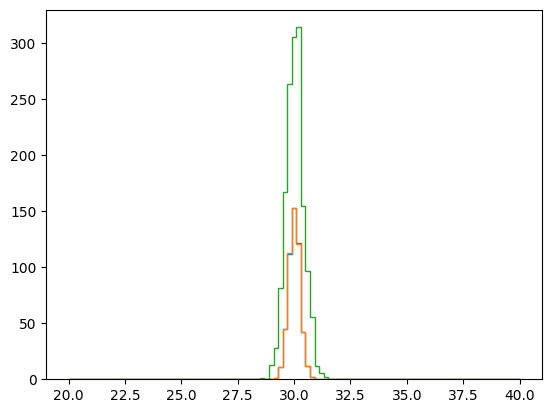

In [344]:
bins=np.linspace(20,40,100)
plt.hist(v1s,bins,histtype="step")
plt.hist(v2s,bins,histtype="step");
plt.hist(vest,bins,histtype="step");

In [345]:
np.std(v2s),np.std(vest)

(0.25246958023601995, 0.3909155423611694)

In [349]:
1.4/(80*5/30)

0.10499999999999998

In [291]:
0.003/0.0296

0.10135135135135134

Fit results for y:
  Slope (m): -0.010110772367450798 ± 0.004442835544721897
  Intercept (c): 16.8687193843362 ± 6.421442225720332

Fit results for z:
  Slope (n): 0.02331061882260214 ± 0.002988071523335984
  Intercept (d): -26.184203043693767 ± 4.203173404306164


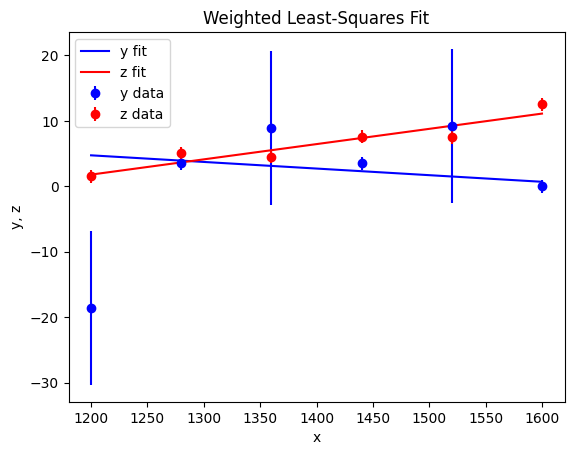

In [299]:
import numpy as np
import matplotlib.pyplot as plt

def weighted_least_squares_fit(x, y, z, y_err, z_err):
    """
    Perform a weighted least-squares fit for the line y = mx + c and z = nx + d.

    Parameters:
    x (array): Independent variable.
    y (array): Dependent variable y-coordinates.
    z (array): Dependent variable z-coordinates.
    y_err (array): Uncertainties in y.
    z_err (array): Uncertainties in z.

    Returns:
    dict: Fit parameters and their uncertainties for y and z.
    """
    # Weights are the inverse of variance (uncertainty squared)
    w_y = 1 / (y_err ** 2)
    w_z = 1 / (z_err ** 2)

    # Calculate weighted sums for y
    S_y = np.sum(w_y)
    S_x_y = np.sum(w_y * x)
    S_x2_y = np.sum(w_y * x ** 2)
    S_xy_y = np.sum(w_y * x * y)
    S_y_y = np.sum(w_y * y)

    # Solve for slope (m) and intercept (c) for y
    delta_y = S_y * S_x2_y - S_x_y ** 2
    m_y = (S_y * S_xy_y - S_x_y * S_y_y) / delta_y
    c_y = (S_x2_y * S_y_y - S_x_y * S_xy_y) / delta_y

    # Uncertainties in slope and intercept for y
    m_y_err = np.sqrt(S_y / delta_y)
    c_y_err = np.sqrt(S_x2_y / delta_y)

    # Calculate weighted sums for z
    S_z = np.sum(w_z)
    S_x_z = np.sum(w_z * x)
    S_x2_z = np.sum(w_z * x ** 2)
    S_xy_z = np.sum(w_z * x * z)
    S_y_z = np.sum(w_z * z)

    # Solve for slope (n) and intercept (d) for z
    delta_z = S_z * S_x2_z - S_x_z ** 2
    n_z = (S_z * S_xy_z - S_x_z * S_y_z) / delta_z
    d_z = (S_x2_z * S_y_z - S_x_z * S_xy_z) / delta_z

    # Uncertainties in slope and intercept for z
    n_z_err = np.sqrt(S_z / delta_z)
    d_z_err = np.sqrt(S_x2_z / delta_z)

    return {
        "y_fit": {"slope": m_y, "intercept": c_y, "slope_err": m_y_err, "intercept_err": c_y_err},
        "z_fit": {"slope": n_z, "intercept": d_z, "slope_err": n_z_err, "intercept_err": d_z_err},
    }

# Example usage
hits=Hit_collection[11]
x = np.array([hit.y for hit in hits])
y = np.array([hit.x for hit in hits])
z = np.array([hit.t for hit in hits])
y_err = np.array([hit.x_err for hit in hits])
z_err = np.array([hit.t_err for hit in hits])

fit_results = weighted_least_squares_fit(x, y, z, y_err, z_err)

# Print fit results
print("Fit results for y:")
print(f"  Slope (m): {fit_results['y_fit']['slope']} ± {fit_results['y_fit']['slope_err']}")
print(f"  Intercept (c): {fit_results['y_fit']['intercept']} ± {fit_results['y_fit']['intercept_err']}")

print("\nFit results for z:")
print(f"  Slope (n): {fit_results['z_fit']['slope']} ± {fit_results['z_fit']['slope_err']}")
print(f"  Intercept (d): {fit_results['z_fit']['intercept']} ± {fit_results['z_fit']['intercept_err']}")

# Plotting the results
plt.errorbar(x, y, yerr=y_err, fmt='o', label='y data', color='blue')
plt.plot(x, fit_results['y_fit']['slope'] * x + fit_results['y_fit']['intercept'], label='y fit', color='blue')

plt.errorbar(x, z, yerr=z_err, fmt='o', label='z data', color='red')
plt.plot(x, fit_results['z_fit']['slope'] * x + fit_results['z_fit']['intercept'], label='z fit', color='red')

plt.legend()
plt.xlabel('x')
plt.ylabel('y, z')
plt.title('Weighted Least-Squares Fit')
plt.show()


In [324]:
1/80

0.0125